<a href="https://colab.research.google.com/github/natthamonsmn/Cinema_Team/blob/4/Cinema_function_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍿🎥✮⋆˙ ธุรกิจโรงภาพยนตร์ (Cinema)
โดยเน้น **ระบบจองที่นั่งดูหนัง** เช่น การจองที่นั่งของลูกค้า, ตรวจสอบที่นั่งว่าง, คำนวณราคาตามประเภทที่นั่งและประเภทสมาชิก

## 1. โครงสร้างโปรแกรม

## ส่วนที่ 1 — class และฟังก์ชัน

In [4]:
from datetime import datetime, timedelta
import random
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [5]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}

df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

In [6]:
class Customer:
    def __init__(self, customer_id, name, member_type="General"):
        self.customer_id = customer_id
        self.name = name
        self.member_type = member_type
        self.points = 0

    def get_discount_rate(self, promo_discount_rate=0.0):
        member_discounts = {"General": 0.0, "Student": 0.20, "VIP": 0.30}
        member_rate = member_discounts.get(self.member_type, 0.0)
        return max(member_rate, promo_discount_rate)

    def add_points(self, net_price):
        earned = int(net_price // 10)
        self.points += earned
        return earned


class Showtime:
    def __init__(self, showtime_id, movie_name, theater_no, start_time, end_time, base_price):
        self.showtime_id = showtime_id
        self.movie_name = movie_name
        self.theater_no = theater_no
        self.start_time = start_time
        self.end_time = end_time
        self.base_price = base_price


class Booking:
    def __init__(self, booking_id, customer, showtime, seat_number, seat_type):
        self.booking_id = booking_id
        self.customer = customer
        self.showtime = showtime
        self.seat_number = seat_number.upper()
        self.seat_type = seat_type
        self.booking_time = datetime.now()
        self.status = "Pending"
        # เรียกใช้ Helper Function คิดราคา
        self.net_price = calculate_booking_price(showtime.base_price, seat_type, customer.member_type)

    def check_timeout(self):
        if self.status == "Pending":
            if datetime.now() > self.booking_time + timedelta(minutes=10):
                self.status = "Cancelled"
                return True
        return False

    def confirm_payment(self):
        if self.check_timeout():
            raise Exception("เกินเวลา 10 นาที (Timeout Auto-Cancel)")
        self.status = "Paid"
        self.customer.add_points(self.net_price)
        return self.net_price

# Helper Functions
def calculate_booking_price(base_price, seat_type="Normal", member_type="General", promo_discount=0.0):
    """ฟังก์ชันที่ 1: คำนวณราคาสุทธิ (มี Default Argument)"""
    seat_extras = {"Normal": 0, "Deluxe": 40, "Honeymoon": 80, "VIP": 190}
    member_discounts = {"General": 0.0, "Student": 0.20, "VIP": 0.30}

    total_seat_price = base_price + seat_extras.get(seat_type, 0)
    best_discount = max(member_discounts.get(member_type, 0.0), promo_discount)
    return round(total_seat_price * (1 - best_discount), 2)


def validate_seat_booking(seat_number, existing_seats_list, valid_seat_range=None):
    """ฟังก์ชันที่ 2: ตรวจสอบผังและที่นั่งซ้ำ (มี Default Argument)"""
    if valid_seat_range is None:
        valid_seat_range = [f"{row}{num}" for row in "ABCDEF" for num in range(1, 11)]

    seat_upper = seat_number.upper()
    if seat_upper not in valid_seat_range:
        return False, f"ที่นั่ง {seat_number} ไม่มีอยู่ในระบบ (Invalid Seat)"
    if seat_upper in existing_seats_list:
        return False, f"ที่นั่ง {seat_number} ถูกจองแล้ว (Double Booking)"
    return True, "ที่นั่งว่าง สามารถจองได้"


def process_ticket_scan(ticket_id, current_status="Paid", auto_update=True):
    """ฟังก์ชันที่ 3: จำลองการสแกน QR Code เข้าโรง (มี Default Argument)"""
    if current_status == "Used":
        return False, f"ตั๋ว {ticket_id} ถูกใช้งานไปแล้ว ไม่สามารถสแกนซ้ำได้!"
    elif current_status != "Paid":
        return False, f"ตั๋ว {ticket_id} ยังไม่ได้ชำระเงิน"

    new_status = "Used" if auto_update else current_status
    return True, f"สแกนสำเร็จ! ({new_status})"



# Execution Simulation Loop (จำลอง 300 รายการทีละคน)

showtime_1 = Showtime(
    "ST01",
    "Avatar 3",
    1,
    datetime(2026, 8, 20, 14, 0),
    datetime(2026, 8, 20, 17, 0),
    160,
)
showtime_2 = Showtime(
    "ST02",
    "Spider-Man",
    2,
    datetime(2026, 8, 20, 15, 30),
    datetime(2026, 8, 20, 18, 0),
    180,
)
showtime_3 = Showtime(
    "ST03",
    "Batman",
    3,
    datetime(2026, 8, 20, 19, 0),
    datetime(2026, 8, 20, 22, 0),
    200,
)

showtimes_pool = [showtime_1, showtime_2, showtime_3]

# แยกเก็บรายการที่นั่งที่ถูกจองแล้วของแต่ละโรง (ป้องกันการจองชนกันข้ามโรง)
booked_seats_by_theater = {1: [], 2: [], 3: []}

all_bookings = []
member_pool = ["General", "Student", "VIP"]
seat_type_pool = ["Normal", "Deluxe", "Honeymoon", "VIP"]
seat_pool = [f"{r}{n}" for r in "ABCDEF" for n in range(1, 11)] + ["Z99"]

# Loop จำลอง 300 รายการ (สุ่มเลือกโรงภาพยนตร์)
for i in range(1, 301):
    cust_id = f"C{i:03d}"
    cust_name = f"Customer_{i}"
    chosen_member = random.choice(member_pool)
    chosen_seat = random.choice(seat_pool)
    chosen_seat_type = random.choice(seat_type_pool)
    booking_id = f"BK{i:03d}"

    # สุ่มเลือกโรงภาพยนตร์ 1 จาก 3 โรง
    chosen_showtime = random.choice(showtimes_pool)
    theater_no = chosen_showtime.theater_no

    customer = Customer(cust_id, cust_name, chosen_member)

    # ตรวจสอบที่นั่งซ้ำเฉพาะในโรงภาพยนตร์ที่เลือก
    is_valid, seat_msg = validate_seat_booking(
        chosen_seat, booked_seats_by_theater[theater_no]
    )

    if not is_valid:
        failed_booking = Booking(
            booking_id,
            customer,
            chosen_showtime,
            chosen_seat,
            chosen_seat_type,
        )
        failed_booking.status = f"Rejected ({seat_msg})"
        failed_booking.net_price = 0.0
        all_bookings.append(failed_booking)
        continue

    try:
        new_booking = Booking(
            booking_id,
            customer,
            chosen_showtime,
            chosen_seat,
            chosen_seat_type,
        )

        if random.random() < 0.10:
            new_booking.booking_time = datetime.now() - timedelta(minutes=15)

        new_booking.confirm_payment()
        booked_seats_by_theater[theater_no].append(
            chosen_seat
        )
        all_bookings.append(new_booking)

    except Exception:
        new_booking.net_price = 0.0
        all_bookings.append(new_booking)


## ส่วนที่ 2 — ทดสอบฟังก์ชันทีละตัว

In [7]:
seat_pool = [f"{r}{n}" for r in "ABCDEF" for n in range(1, 11)]
# ทดสอบเรียกสุ่มที่นั่ง 3 ครั้ง ดูว่าฟังก์ชันสุ่มทำงานได้ค่าไม่ซ้ำกันในแต่ละรอบ
for _ in range(3):
    print("ที่นั่งที่สุ่มได้:", random.choice(seat_pool))

ที่นั่งที่สุ่มได้: B6
ที่นั่งที่สุ่มได้: B8
ที่นั่งที่สุ่มได้: E4


In [8]:
booked_test_list = ["A1"]

# ทดสอบการตรวจที่นั่ง (ที่นั่งซ้ำ, ที่นั่งว่าง, ที่นั่งไม่มีอยู่จริง)
for seat_to_check in ["A1", "B5", "Z99"]:
    is_valid, message = validate_seat_booking(seat_to_check, booked_test_list)
    print(f"ผลการตรวจที่นั่ง '{seat_to_check}':", message)

ผลการตรวจที่นั่ง 'A1': ที่นั่ง A1 ถูกจองแล้ว (Double Booking)
ผลการตรวจที่นั่ง 'B5': ที่นั่งว่าง สามารถจองได้
ผลการตรวจที่นั่ง 'Z99': ที่นั่ง Z99 ไม่มีอยู่ในระบบ (Invalid Seat)


In [9]:
# เปรียบเทียบการเรียก calculate_booking_price() แบบไม่ระบุค่า (ใช้ default) กับแบบระบุช่วงเอง
print("เรียกแบบ default (ไม่ใส่ argument):", calculate_booking_price(160))
print(
    "เรียกแบบระบุช่วงเอง (ที่นั่ง VIP, สมาชิก VIP):",
    calculate_booking_price(160, "VIP", "VIP"),
)
print(
    "เรียกแบบระบุแค่ promo_discount (keyword argument):",
    calculate_booking_price(160, promo_discount=0.50),
)

เรียกแบบ default (ไม่ใส่ argument): 160.0
เรียกแบบระบุช่วงเอง (ที่นั่ง VIP, สมาชิก VIP): 245.0
เรียกแบบระบุแค่ promo_discount (keyword argument): 80.0


## ส่วนที่ 3 — ฟังก์ชันอธิบายขั้นตอนคำนวณราคา

In [10]:
def explain_booking_price(booking):
    """รับ object Booking 1 ตัว -> พิมพ์อธิบายการคำนวณราคาทีละขั้นตอน"""
    seat_extras = {"Normal": 0, "Deluxe": 40, "Honeymoon": 80, "VIP": 190}

    extra_price = seat_extras.get(booking.seat_type, 0)
    base_price = booking.showtime.base_price
    full_price = base_price + extra_price

    discount_rate = booking.customer.get_discount_rate()

    final_price = booking.net_price

    print(
        f"ราคาตั๋วภาพยนตร์เรื่อง '{booking.showtime.movie_name}' (โรง"
        f" {booking.showtime.theater_no}) = {base_price} บาท"
    )
    print(
        f"บวกเพิ่มที่นั่งประเภท '{booking.seat_type}' = +{extra_price} บาท"
        f" (ราคารวมก่อนส่วนลด = {full_price} บาท)"
    )

    if discount_rate > 0:
        print(
            f"ลูกค้าเป็นสมาชิก {booking.customer.member_type} -> ได้ส่วนลด"
            f" {discount_rate * 100:.0f}%"
        )
    else:
        print("ลูกค้าเป็นสมาชิก General -> ไม่มีส่วนลด")

    print(f"ราคาสุทธิ = {final_price:,.2f} บาท")
    return


demo_cust = Customer("C001", "Customer_1", "VIP")
demo_show = Showtime(
    "ST01",
    "Avatar 3",
    1,
    datetime(2026, 8, 20, 18, 0),
    datetime(2026, 8, 20, 21, 0),
    160,
)
demo_booking = Booking("BK001", demo_cust, demo_show, "A1", "Honeymoon")
explain_booking_price(demo_booking)

ราคาตั๋วภาพยนตร์เรื่อง 'Avatar 3' (โรง 1) = 160 บาท
บวกเพิ่มที่นั่งประเภท 'Honeymoon' = +80 บาท (ราคารวมก่อนส่วนลด = 240 บาท)
ลูกค้าเป็นสมาชิก VIP -> ได้ส่วนลด 30%
ราคาสุทธิ = 168.00 บาท


## ตารางบันทึกข้อมูลที่จำลองได้

In [11]:
summary_rows = [
    {
        "booking_id": b.booking_id,
        "customer_id": b.customer.customer_id,
        "name": b.customer.name,
        "member_type": b.customer.member_type,
        "movie_name": b.showtime.movie_name,
        "theater_no": b.showtime.theater_no,
        "seat_number": b.seat_number,
        "seat_type": b.seat_type,
        "price": b.net_price,
        "status": b.status,
    }
    for b in all_bookings
]

demo_summary_df = pd.DataFrame(summary_rows)
demo_summary_df

,booking_id,customer_id,name,member_type,movie_name,theater_no,seat_number,seat_type,price,status
0,BK001,C001,Customer_1,Student,Avatar 3,1,E4,Honeymoon,192.0,Paid
1,BK002,C002,Customer_2,General,Batman,3,A6,Normal,200.0,Paid
2,BK003,C003,Customer_3,General,Avatar 3,1,B9,Honeymoon,240.0,Paid
3,BK004,C004,Customer_4,General,Batman,3,C2,Normal,200.0,Paid
4,BK005,C005,Customer_5,General,Batman,3,E10,Honeymoon,280.0,Paid
...,...,...,...,...,...,...,...,...,...,...
295,BK296,C296,Customer_296,VIP,Batman,3,C10,Deluxe,168.0,Paid
296,BK297,C297,Customer_297,General,Spider-Man,2,A6,VIP,0.0,Rejected (ที่นั่ง A6 ถูกจองแล้ว (Double Booking))
297,BK298,C298,Customer_298,Student,Batman,3,C3,Normal,0.0,Rejected (ที่นั่ง C3 ถูกจองแล้ว (Double Booking))
298,BK299,C299,Customer_299,VIP,Avatar 3,1,F9,Deluxe,0.0,Rejected (ที่นั่ง F9 ถูกจองแล้ว (Double Booking))


In [18]:
demo_summary_df.to_csv("demo_cinema.csv")

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
demo_summary_df.to_csv("/content/drive/MyDrive/demo_cinema.csv", index=False)

## ฐานข้อมูล SQLite

In [12]:
import sqlite3
import pandas as pd

# เชื่อมต่อฐานข้อมูล SQLite
conn = sqlite3.connect("cinema.db")

time_slots = ["11:00", "13:30", "16:00", "18:30", "21:00"]

# ตารางที่ 1: customers (ตารางลูกค้า - ดึงเฉพาะข้อมูลลูกค้าไม่ให้ซ้ำ)
customers_list = [
    {
        "customer_id": b.customer.customer_id,
        "name": b.customer.name,
        "member_type": b.customer.member_type,
        "points": b.customer.points,
    }
    for b in all_bookings
]
# ใช้ .drop_duplicates() เพื่อให้เหลือลูกค้า 1 คน ต่อ 1 แถวในตารางแม่
customers_df = pd.DataFrame(customers_list).drop_duplicates(
    subset=["customer_id"]
)

# บันทึกลงตาราง customers
customers_df.to_sql("customers", conn, if_exists="replace", index=False)


# ตารางที่ 2: bookings (ตารางธุรกรรมการจอง - ผูกด้วย customer_id)
bookings_list = [
    {
        "booking_id": b.booking_id,
        "customer_id": b.customer.customer_id,  # ใช้เป็น Foreign Key เชื่อมกับตารางแม่
        "movie_name": b.showtime.movie_name,
        "showtime": random.choice(time_slots),
        "theater_no": b.showtime.theater_no,
        "seat_number": b.seat_number,
        "seat_type": b.seat_type,
        "price": b.net_price,
        "status": b.status,
    }
    for b in all_bookings
]

bookings_df = pd.DataFrame(bookings_list)

# บันทึกลงตาราง bookings
bookings_df.to_sql("bookings", conn, if_exists="replace", index=False)


# ทดสอบดึงข้อมูลดูว่าเข้าฐานข้อมูลจริงไหม
check_customers = pd.read_sql_query(
    "SELECT * FROM customers LIMIT 5", conn
)
check_bookings = pd.read_sql_query("SELECT * FROM bookings LIMIT 5", conn)

print("--- ตารางที่ 1: customers ---")
print(check_customers)
print("\n--- ตารางที่ 2: bookings ---")
print(check_bookings)

--- ตารางที่ 1: customers ---
  customer_id        name member_type  points
0        C001  Customer_1     Student      19
1        C002  Customer_2     General      20
2        C003  Customer_3     General      24
3        C004  Customer_4     General      20
4        C005  Customer_5     General      28

--- ตารางที่ 2: bookings ---
  booking_id customer_id movie_name showtime  theater_no seat_number  \
0      BK001        C001   Avatar 3    18:30           1          E4   
1      BK002        C002     Batman    13:30           3          A6   
2      BK003        C003   Avatar 3    16:00           1          B9   
3      BK004        C004     Batman    13:30           3          C2   
4      BK005        C005     Batman    21:00           3         E10   

   seat_type  price status  
0  Honeymoon  192.0   Paid  
1     Normal  200.0   Paid  
2  Honeymoon  240.0   Paid  
3     Normal  200.0   Paid  
4  Honeymoon  280.0   Paid  


In [13]:
query_join = """
SELECT
    b.booking_id,
    c.name AS customer_name,
    c.member_type,
    b.movie_name,
    b.showtime,
    b.theater_no,
    b.seat_number,
    b.price,
    b.status
FROM bookings b
JOIN customers c ON b.customer_id = c.customer_id
LIMIT 5
"""

# ดึงข้อมูลออกมาเป็น DataFrame
df_joined = pd.read_sql_query(query_join, conn)
print(df_joined)

# ปิด connection หลังใช้งานเสร็จ
conn.close()

  booking_id customer_name member_type movie_name showtime  theater_no  \
0      BK001    Customer_1     Student   Avatar 3    18:30           1   
1      BK002    Customer_2     General     Batman    13:30           3   
2      BK003    Customer_3     General   Avatar 3    16:00           1   
3      BK004    Customer_4     General     Batman    13:30           3   
4      BK005    Customer_5     General     Batman    21:00           3   

  seat_number  price status  
0          E4  192.0   Paid  
1          A6  200.0   Paid  
2          B9  240.0   Paid  
3          C2  200.0   Paid  
4         E10  280.0   Paid  


## ส่วนที่ 4

In [14]:
def simulate_customer_visit(
    customer,
    showtime,
    seat_number,
    seat_type,
    existing_seats,
    promo_discount=0.0
):

    print("" * 40)
    print("เริ่มกระบวนการจองตั๋วภาพยนตร์")
    print("" * 40)

    # Step 1 ลูกค้าเข้ามา
    print("\n ลูกค้าเดินเข้ามาจองตั๋ว")
    print(f"รหัสลูกค้า: {customer.customer_id}")
    print(f"ชื่อลูกค้า: {customer.name}")
    print(f"ประเภทสมาชิก: {customer.member_type}")

    # Step 2 เลือกรอบหนัง
    print("\n เลือกรอบภาพยนตร์")
    print(f"ภาพยนตร์: {showtime.movie_name}")
    print(f"โรงภาพยนตร์: {showtime.theater_no}")
    print(f"เวลาเริ่ม: {showtime.start_time}")

    # Step 3 ตรวจสอบที่นั่ง
    print("\n ตรวจสอบที่นั่ง")

    is_valid, seat_msg = validate_seat_booking(
        seat_number,
        existing_seats
    )

    print(seat_msg)

    if not is_valid:
        print("\nไม่สามารถทำรายการจองได้")
        return None

    # Step 4 คำนวณราคา
    print("\n คำนวณราคาตั๋ว")

    seat_extras = {
        "Normal": 0,
        "Deluxe": 40,
        "Honeymoon": 80,
        "VIP": 190
    }

    # ราคาปกติ = ราคาตั๋วพื้นฐาน + ค่าเพิ่มประเภทที่นั่ง
    normal_price = (
        showtime.base_price +
        seat_extras.get(seat_type, 0)
    )

    # ราคาสุทธิหลังหักส่วนลด
    net_price = calculate_booking_price(
        showtime.base_price,
        seat_type,
        customer.member_type,
        promo_discount
    )

    print(f"ประเภทที่นั่ง: {seat_type}")
    print(f"ราคาปกติ: {normal_price} บาท")
    print(f"ราคาสุทธิ: {net_price} บาท")

    # Step 5 สร้าง Booking
    print("\n สร้างรายการจอง")

    booking_id = f"BK{customer.customer_id}"

    booking = Booking(
        booking_id,
        customer,
        showtime,
        seat_number,
        seat_type
    )

    # ใช้ราคาที่คำนวณจากโปรโมชั่น
    booking.net_price = net_price

    print("สร้างรายการจองสำเร็จ")
    print(f"Booking ID: {booking.booking_id}")
    print(f"สถานะ: {booking.status}")

    # Step 6 ชำระเงิน
    print("\n ลูกค้าชำระเงิน")

    try:
        paid_price = booking.confirm_payment()

        print(f"ชำระเงินสำเร็จ: {paid_price} บาท")
        print(f"สถานะปัจจุบัน: {booking.status}")

        # เพิ่มที่นั่งเข้าไปในรายการที่จองแล้ว
        existing_seats.append(seat_number.upper())

    except Exception as e:
        print(f"ชำระเงินไม่สำเร็จ: {e}")
        return booking

    # Step 7 สะสมคะแนน
    print("\n สะสมคะแนนสมาชิก")
    print(f"คะแนนสะสมปัจจุบัน: {customer.points} คะแนน")

    # Step 8 สแกนตั๋ว
    print("\n สแกนตั๋วเข้าโรงภาพยนตร์")

    success, scan_msg = process_ticket_scan(
        booking.booking_id,
        booking.status
    )

    print(scan_msg)

    # สรุปผล
    print("\n" + "" * 40)
    print("สรุปการใช้บริการ")
    print("" * 40)

    print(f"ลูกค้า: {customer.name}")
    print(f"ภาพยนตร์: {showtime.movie_name}")
    print(f"โรงภาพยนตร์: {showtime.theater_no}")
    print(f"ที่นั่ง: {booking.seat_number}")
    print(f"ประเภทที่นั่ง: {booking.seat_type}")
    print(f"ราคาปกติ: {normal_price} บาท")
    print(f"ราคาสุทธิ: {booking.net_price} บาท")
    print(f"สถานะการจอง: {booking.status}")
    print(f"คะแนนสะสม: {customer.points} คะแนน")

    return booking

In [15]:
customer_1 = Customer(
    customer_id="C001",
    name="customer_n",
    member_type="Student"
)

showtime_1 = Showtime(
    "ST01",
    "Avatar 3",
    1,
    datetime(2026, 8, 20, 14, 0),
    datetime(2026, 8, 20, 17, 0),
    160
)

existing_seats = ["A1", "A2", "B5"]

booking_result = simulate_customer_visit(
    customer=customer_1,
    showtime=showtime_1,
    seat_number="C3",
    seat_type="Deluxe",
    existing_seats=existing_seats,
    promo_discount=0.10
)


เริ่มกระบวนการจองตั๋วภาพยนตร์


 ลูกค้าเดินเข้ามาจองตั๋ว
รหัสลูกค้า: C001
ชื่อลูกค้า: customer_n
ประเภทสมาชิก: Student

 เลือกรอบภาพยนตร์
ภาพยนตร์: Avatar 3
โรงภาพยนตร์: 1
เวลาเริ่ม: 2026-08-20 14:00:00

 ตรวจสอบที่นั่ง
ที่นั่งว่าง สามารถจองได้

 คำนวณราคาตั๋ว
ประเภทที่นั่ง: Deluxe
ราคาปกติ: 200 บาท
ราคาสุทธิ: 160.0 บาท

 สร้างรายการจอง
สร้างรายการจองสำเร็จ
Booking ID: BKC001
สถานะ: Pending

 ลูกค้าชำระเงิน
ชำระเงินสำเร็จ: 160.0 บาท
สถานะปัจจุบัน: Paid

 สะสมคะแนนสมาชิก
คะแนนสะสมปัจจุบัน: 16 คะแนน

 สแกนตั๋วเข้าโรงภาพยนตร์
สแกนสำเร็จ! (Used)


สรุปการใช้บริการ

ลูกค้า: customer_n
ภาพยนตร์: Avatar 3
โรงภาพยนตร์: 1
ที่นั่ง: C3
ประเภทที่นั่ง: Deluxe
ราคาปกติ: 200 บาท
ราคาสุทธิ: 160.0 บาท
สถานะการจอง: Paid
คะแนนสะสม: 16 คะแนน


## ส่วนที่ 5

In [16]:
import random

# สร้างรอบหนังหลายรอบ
showtime_1 = Showtime(
    "ST01",
    "Avatar 3",
    1,
    datetime(2026, 8, 20, 14, 0),
    datetime(2026, 8, 20, 17, 0),
    160
)

showtime_2 = Showtime(
    "ST02",
    "Spider-Man",
    2,
    datetime(2026, 8, 20, 15, 30),
    datetime(2026, 8, 20, 18, 0),
    180
)

showtime_3 = Showtime(
    "ST03",
    "Batman",
    3,
    datetime(2026, 8, 20, 19, 0),
    datetime(2026, 8, 20, 22, 0),
    200
)

# รวมรอบหนังไว้สำหรับสุ่มเลือก
showtimes_pool = [
    showtime_1,
    showtime_2,
    showtime_3
]

# เก็บที่นั่งที่ถูกจองแยกตามโรง
booked_seats_by_theater = {
    1: [],
    2: [],
    3: []
}

# ข้อมูลสำหรับสุ่ม
member_pool = ["General", "Student", "VIP"]

seat_type_pool = [
    "Normal",
    "Deluxe",
    "Honeymoon",
    "VIP"
]

seat_pool = [
    f"{row}{num}"
    for row in "ABCDEF"
    for num in range(1, 11)
] + ["Z99"]


for i in range(1, 6):

    print("\n")
    print("" * 50)
    print(f"ลูกค้าคนที่ {i}")
    print("" * 50)

    # สุ่มประเภทสมาชิก
    chosen_member = random.choice(member_pool)

    # สุ่มรอบหนัง
    chosen_showtime = random.choice(showtimes_pool)

    # สุ่มที่นั่ง
    chosen_seat = random.choice(seat_pool)

    # สุ่มประเภทที่นั่ง
    chosen_seat_type = random.choice(
        seat_type_pool
    )

    # สร้างลูกค้า
    customer = Customer(
        customer_id=f"C{i:03d}",
        name=f"Customer_{i}",
        member_type=chosen_member
    )

    # เรียกใช้ฟังก์ชันเดิม
    booking_result = simulate_customer_visit(
        customer=customer,
        showtime=chosen_showtime,
        seat_number=chosen_seat,
        seat_type=chosen_seat_type,

        # ส่งรายการที่นั่งของโรงที่ลูกค้าเลือก
        existing_seats=
        booked_seats_by_theater[
            chosen_showtime.theater_no
        ],

        # สุ่มโปรโมชั่น 0% หรือ 10%
        promo_discount=random.choice([
            0.0,
            0.10
        ])
    )




ลูกค้าคนที่ 1


เริ่มกระบวนการจองตั๋วภาพยนตร์


 ลูกค้าเดินเข้ามาจองตั๋ว
รหัสลูกค้า: C001
ชื่อลูกค้า: Customer_1
ประเภทสมาชิก: VIP

 เลือกรอบภาพยนตร์
ภาพยนตร์: Spider-Man
โรงภาพยนตร์: 2
เวลาเริ่ม: 2026-08-20 15:30:00

 ตรวจสอบที่นั่ง
ที่นั่งว่าง สามารถจองได้

 คำนวณราคาตั๋ว
ประเภทที่นั่ง: Deluxe
ราคาปกติ: 220 บาท
ราคาสุทธิ: 154.0 บาท

 สร้างรายการจอง
สร้างรายการจองสำเร็จ
Booking ID: BKC001
สถานะ: Pending

 ลูกค้าชำระเงิน
ชำระเงินสำเร็จ: 154.0 บาท
สถานะปัจจุบัน: Paid

 สะสมคะแนนสมาชิก
คะแนนสะสมปัจจุบัน: 15 คะแนน

 สแกนตั๋วเข้าโรงภาพยนตร์
สแกนสำเร็จ! (Used)


สรุปการใช้บริการ

ลูกค้า: Customer_1
ภาพยนตร์: Spider-Man
โรงภาพยนตร์: 2
ที่นั่ง: A10
ประเภทที่นั่ง: Deluxe
ราคาปกติ: 220 บาท
ราคาสุทธิ: 154.0 บาท
สถานะการจอง: Paid
คะแนนสะสม: 15 คะแนน



ลูกค้าคนที่ 2


เริ่มกระบวนการจองตั๋วภาพยนตร์


 ลูกค้าเดินเข้ามาจองตั๋ว
รหัสลูกค้า: C002
ชื่อลูกค้า: Customer_2
ประเภทสมาชิก: Student

 เลือกรอบภาพยนตร์
ภาพยนตร์: Spider-Man
โรงภาพยนตร์: 2
เวลาเริ่ม: 2026-08-20 15:30:00

 ตรวจสอบที่นั่ง
ที่นั่ง

## 2.ตารางวิเคราะห์ด้วย Pandas

In [21]:
import pandas as pd

# โหลดข้อมูลจากไฟล์ CSV กลับเข้ามาใน DataFrame
df = pd.read_csv("demo_cinema.csv")

# 1.1 ตรวจสอบโครงสร้างข้อมูล ประเภทคอลัมน์ และค่าว่าง
print("--- ข้อมูลโครงสร้างและประเภทคอลัมน์ (df.info()) ---")
df.info()

# 1.2 คำนวณค่าสถิติพื้นฐานของข้อมูลเชิงตัวเลข
print("\n--- ค่าสถิติพื้นฐานเชิงตัวเลข (df.describe()) ---")
print(df.describe().round(2))

--- ข้อมูลโครงสร้างและประเภทคอลัมน์ (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   300 non-null    int64  
 1   booking_id   300 non-null    object 
 2   customer_id  300 non-null    object 
 3   name         300 non-null    object 
 4   member_type  300 non-null    object 
 5   movie_name   300 non-null    object 
 6   theater_no   300 non-null    int64  
 7   seat_number  300 non-null    object 
 8   seat_type    300 non-null    object 
 9   price        300 non-null    float64
 10  status       300 non-null    object 
dtypes: float64(1), int64(2), object(8)
memory usage: 25.9+ KB

--- ค่าสถิติพื้นฐานเชิงตัวเลข (df.describe()) ---
       Unnamed: 0  theater_no   price
count      300.00      300.00  300.00
mean       149.50        2.08   96.19
std         86.75        0.83  114.09
min          0.00        1.00  

In [22]:
# สรุปยอดขาย จำนวนตั๋วที่ขายได้ และราคาเฉลี่ย แยกตามประเภทที่นั่ง
seat_revenue_summary = (
    df[df["status"] == "Paid"]
    .groupby("seat_type")
    .agg(
        total_tickets=("booking_id", "count"),
        total_revenue=("price", "sum"),
        avg_price_per_ticket=("price", "mean"),
    )
    .reset_index()
)

print("--- รายได้และจำนวนตั๋วแยกตามประเภทที่นั่ง ---")
print(seat_revenue_summary)

--- รายได้และจำนวนตั๋วแยกตามประเภทที่นั่ง ---
   seat_type  total_tickets  total_revenue  avg_price_per_ticket
0     Deluxe             34         6298.0            185.235294
1  Honeymoon             29         6086.0            209.862069
2     Normal             43         6606.0            153.627907
3        VIP             32         9866.0            308.312500


In [24]:
# ค้นหา Top 5 ลูกค้าที่ทำรายได้ให้โรงภาพยนตร์มากที่สุด
top5_customers = (
    df[df["status"] == "Paid"]
    .groupby(["customer_id", "name", "member_type"])
    .agg(
        total_spent=("price", "sum"),
        tickets_bought=("booking_id", "count"),
    )
    .reset_index()
    .sort_values(by="total_spent", ascending=False)
    .head(5)
)

print("--- Top 5 ลูกค้าที่ใช้จ่ายสูงสุด (High-Value Customers) ---")
print(top5_customers.to_string(index=False))

--- Top 5 ลูกค้าที่ใช้จ่ายสูงสุด (High-Value Customers) ---
customer_id         name member_type  total_spent  tickets_bought
       C249 Customer_249     General        390.0               1
       C240 Customer_240     General        390.0               1
       C038  Customer_38     General        390.0               1
       C092  Customer_92     General        350.0               1
       C007   Customer_7     Student        312.0               1


In [23]:
# ค้นหาภาพยนตร์ที่ทำรายได้รวมสูงสุด
top_movies = (
    df[df["status"] == "Paid"]
    .groupby("movie_name")
    .agg(
        total_revenue=("price", "sum"),
        total_seats_sold=("booking_id", "count"),
    )
    .reset_index()
    .sort_values(by="total_revenue", ascending=False)
    .head(5)
)

print("\n--- ภาพยนตร์ที่ทำรายได้สูงสุด ---")
print(top_movies.to_string(index=False))


--- ภาพยนตร์ที่ทำรายได้สูงสุด ---
movie_name  total_revenue  total_seats_sold
    Batman        10796.0                51
Spider-Man         9573.0                45
  Avatar 3         8487.0                42


# 3. การวิเคราะห์ด้วย SQL

In [24]:
import pandas as pd
import sqlite3

conn = sqlite3.connect(":memory:")

df_customers = pd.read_csv("demo_cinema.csv")
df_customers.to_sql("customers", conn, if_exists="replace", index=False)

movies_list = df_customers['movie_name'].dropna().unique()
df_movies = pd.DataFrame({
    'movie_name': movies_list,
    'genre': ['Action/Sci-Fi', 'Action/Drama', 'Animation/Family', 'Sci-Fi/Thriller'][:len(movies_list)]
})
df_movies.to_sql("movies", conn, if_exists="replace", index=False)

3

In [25]:
# Query 1: (SELECT, WHERE, ORDER BY) - เลือกเฉพาะการจองที่จ่ายเงินแล้ว (Paid) เรียงตามโรง ตามราคาจากมากไปน้อย
query1 = """
    SELECT booking_id, customer_id, movie_name, theater_no, price, status
    FROM customers
    WHERE status = 'Paid'
    ORDER BY theater_no ASC, price DESC
"""
print("Query 1: รายการจองที่จ่ายเงินแล้ว (Paid)")
display(pd.read_sql_query(query1, conn))


Query 1: รายการจองที่จ่ายเงินแล้ว (Paid)


,booking_id,customer_id,movie_name,theater_no,price,status
0,BK026,C026,Avatar 3,1,350.0,Paid
1,BK032,C032,Avatar 3,1,350.0,Paid
2,BK058,C058,Avatar 3,1,350.0,Paid
3,BK065,C065,Avatar 3,1,350.0,Paid
4,BK010,C010,Avatar 3,1,280.0,Paid
...,...,...,...,...,...,...
133,BK095,C095,Batman,3,140.0,Paid
134,BK126,C126,Batman,3,140.0,Paid
135,BK180,C180,Batman,3,140.0,Paid
136,BK204,C204,Batman,3,140.0,Paid


In [26]:
# Query 2: (SELECT, WHERE, ORDER BY) - รายการจองที่ไม่สำเร็จทั้งหมด แยกดูตามโรง
query2 = """
    SELECT booking_id, customer_id, movie_name, theater_no, seat_number, status
    FROM customers
    WHERE status LIKE 'Rejected%'
    ORDER BY theater_no ASC, name ASC
"""
print("Query 2: รายการจองที่ไม่สำเร็จทั้งหมด")
display(pd.read_sql_query(query2, conn))

Query 2: รายการจองที่ไม่สำเร็จทั้งหมด


,booking_id,customer_id,movie_name,theater_no,seat_number,status
0,BK109,C109,Avatar 3,1,D5,Rejected (ที่นั่ง D5 ถูกจองแล้ว (Double Booking))
1,BK114,C114,Avatar 3,1,E7,Rejected (ที่นั่ง E7 ถูกจองแล้ว (Double Booking))
2,BK137,C137,Avatar 3,1,A1,Rejected (ที่นั่ง A1 ถูกจองแล้ว (Double Booking))
3,BK142,C142,Avatar 3,1,C8,Rejected (ที่นั่ง C8 ถูกจองแล้ว (Double Booking))
4,BK145,C145,Avatar 3,1,B9,Rejected (ที่นั่ง B9 ถูกจองแล้ว (Double Booking))
...,...,...,...,...,...,...
137,BK063,C063,Batman,3,B5,Rejected (ที่นั่ง B5 ถูกจองแล้ว (Double Booking))
138,BK069,C069,Batman,3,A3,Rejected (ที่นั่ง A3 ถูกจองแล้ว (Double Booking))
139,BK076,C076,Batman,3,Z99,Rejected (ที่นั่ง Z99 ไม่มีอยู่ในระบบ (Invalid...
140,BK080,C080,Batman,3,Z99,Rejected (ที่นั่ง Z99 ไม่มีอยู่ในระบบ (Invalid...


In [27]:
# Query 3: (SELECT, WHERE, ORDER BY) - สมาชิก VIP ที่ชำระเงินสำเร็จจากทุกโรง
query3 = """
    SELECT booking_id, customer_id, movie_name, member_type, theater_no, seat_type, price
    FROM customers
    WHERE member_type = 'VIP' AND status = 'Paid'
    ORDER BY theater_no ASC, price DESC
"""
print("Query 3: สมาชิก VIP ที่ชำระเงินสำเร็จ")
display(pd.read_sql_query(query3, conn))

Query 3: สมาชิก VIP ที่ชำระเงินสำเร็จ


,booking_id,customer_id,movie_name,member_type,theater_no,seat_type,price
0,BK008,C008,Avatar 3,VIP,1,VIP,245.0
1,BK057,C057,Avatar 3,VIP,1,VIP,245.0
2,BK102,C102,Avatar 3,VIP,1,VIP,245.0
3,BK012,C012,Avatar 3,VIP,1,Honeymoon,168.0
4,BK048,C048,Avatar 3,VIP,1,Honeymoon,168.0
5,BK078,C078,Avatar 3,VIP,1,Honeymoon,168.0
6,BK112,C112,Avatar 3,VIP,1,Honeymoon,168.0
7,BK120,C120,Avatar 3,VIP,1,Honeymoon,168.0
8,BK029,C029,Avatar 3,VIP,1,Deluxe,140.0
9,BK030,C030,Avatar 3,VIP,1,Deluxe,140.0


In [28]:
# Query 4: (GROUP BY + Aggregate) - สรุปจำนวนตั๋ว ยอดขายรวม และราคาเฉลี่ยต่อตั๋ว แยกตามโรงและภาพยนตร์
query4 = """
    SELECT
        theater_no,
        movie_name,
        COUNT(booking_id) AS total_tickets,
        SUM(price) AS total_revenue,
        AVG(price) AS average_price
    FROM customers
    WHERE status = 'Paid'
    GROUP BY theater_no, movie_name
    ORDER BY theater_no ASC
"""
print("Query 4: สรุปยอดขายและจำนวนตั๋ว (GROUP BY + Aggregate)")
display(pd.read_sql_query(query4, conn))

Query 4: สรุปยอดขายและจำนวนตั๋ว (GROUP BY + Aggregate)


,theater_no,movie_name,total_tickets,total_revenue,average_price
0,1,Avatar 3,42,8487.0,202.071429
1,2,Spider-Man,45,9573.0,212.733333
2,3,Batman,51,10796.0,211.686275


In [29]:
# Query 5: (JOIN) - เชื่อมตาราง customers และ movies เพื่อแสดงหมวดหมู่หนัง (genre)
query5 = """
    SELECT
        customers.booking_id,
        customers.customer_id,
        customers.member_type,
        customers.movie_name,
        movies.genre,
        customers.theater_no,
        customers.seat_number,
        customers.price,
        customers.status
    FROM customers
    JOIN movies
      ON customers.movie_name = movies.movie_name
    WHERE customers.status = 'Paid'
    ORDER BY customers.theater_no ASC, customers.booking_id ASC
"""
print("Query 5: ข้อมูลการจองพร้อมหมวดหมู่ภาพยนตร์ (JOIN)")
display(pd.read_sql_query(query5, conn))

Query 5: ข้อมูลการจองพร้อมหมวดหมู่ภาพยนตร์ (JOIN)


,booking_id,customer_id,member_type,movie_name,genre,theater_no,seat_number,price,status
0,BK001,C001,Student,Avatar 3,Action/Sci-Fi,1,E4,192.0,Paid
1,BK003,C003,General,Avatar 3,Action/Sci-Fi,1,B9,240.0,Paid
2,BK008,C008,VIP,Avatar 3,Action/Sci-Fi,1,E10,245.0,Paid
3,BK010,C010,Student,Avatar 3,Action/Sci-Fi,1,B10,280.0,Paid
4,BK012,C012,VIP,Avatar 3,Action/Sci-Fi,1,C8,168.0,Paid
...,...,...,...,...,...,...,...,...,...
133,BK223,C223,Student,Batman,Action/Drama,3,A4,192.0,Paid
134,BK256,C256,General,Batman,Action/Drama,3,E6,200.0,Paid
135,BK263,C263,General,Batman,Action/Drama,3,C8,240.0,Paid
136,BK284,C284,Student,Batman,Action/Drama,3,D1,224.0,Paid


###4. การนำเสนอผลด้วยกราฟ

movie_name
Batman        10796.0
Spider-Man     9573.0
Avatar 3       8487.0
Name: price, dtype: float64


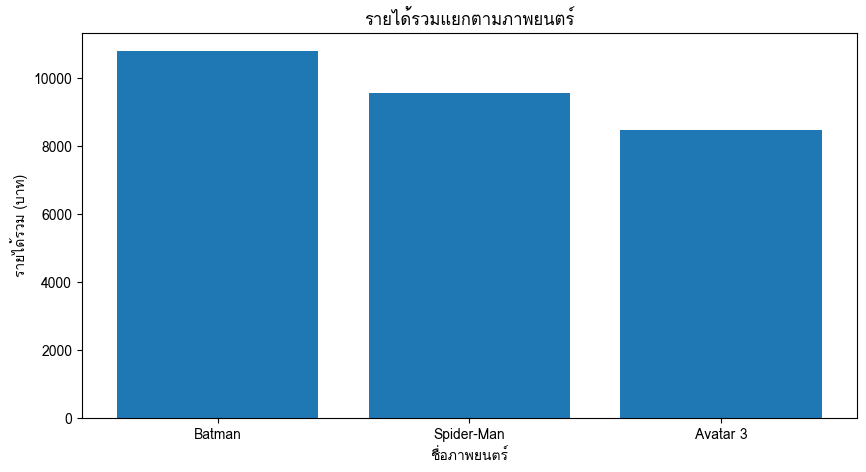

In [53]:
#ภาพยนตร์เรื่องไหนทำรายได้รวมมากที่สุด
import pandas as pd
df = pd.DataFrame(summary_rows)
# 1. กรองเฉพาะรายการที่ชำระเงินสำเร็จ (Paid)
paid_df = df[df["status"] == "Paid"]

# 2. รวมรายได้ตามชื่อภาพยนตร์ และเรียงลำดับจากมากไปน้อย
top_revenue_movie = (
    paid_df.groupby("movie_name")["price"]
    .sum()
    .sort_values(ascending=False)
  )
print(top_revenue_movie)
plt.figure(figsize=(10, 5))
plt.bar(top_revenue_movie.index, top_revenue_movie.values)
plt.title("รายได้รวมแยกตามภาพยนตร์")
plt.xlabel("ชื่อภาพยนตร์")
plt.ylabel("รายได้รวม (บาท)")
plt.show()

movie_name
Batman        51
Spider-Man    45
Avatar 3      42
dtype: int64


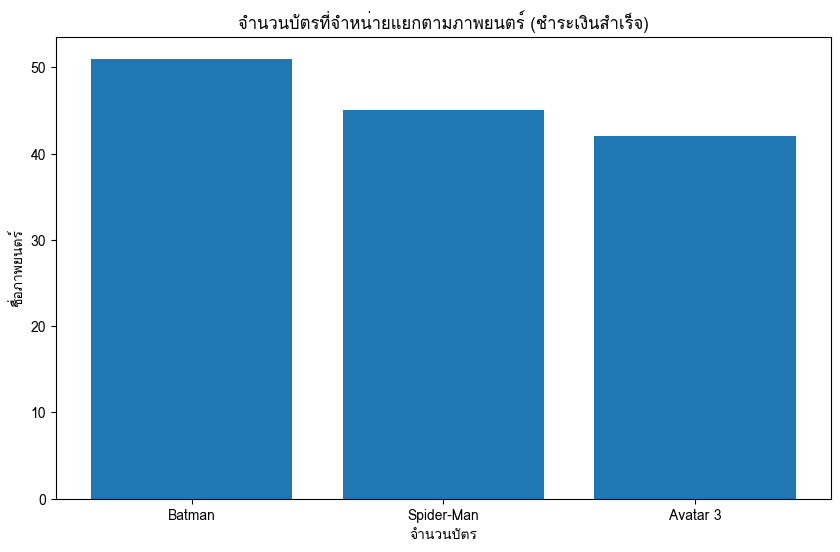

In [56]:
#จำนวนบัตรที่จำหน่ายแยกตามภาพยนตร์(ชำระเงินสำเร็จ)
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(summary_rows)

# กรองเฉพาะรายการที่ชำระเงินสำเร็จ (Paid) และนับจำนวนตั๋วแยกตามภาพยนตร์
tickets_by_movie = (
    df[df["status"] == "Paid"]
    .groupby("movie_name")
    .size().sort_values(ascending=False)
    )
print(tickets_by_movie)
plt.figure(figsize=(10, 6))
bars = plt.bar(tickets_by_movie.index, tickets_by_movie.values)
plt.title("จำนวนบัตรที่จำหน่ายแยกตามภาพยนตร์ (ชำระเงินสำเร็จ)")
plt.xlabel("จำนวนบัตร")
plt.ylabel("ชื่อภาพยนตร์")
plt.show()

movie_name
Batman        115
Spider-Man     93
Avatar 3       92
Name: booking_id, dtype: int64


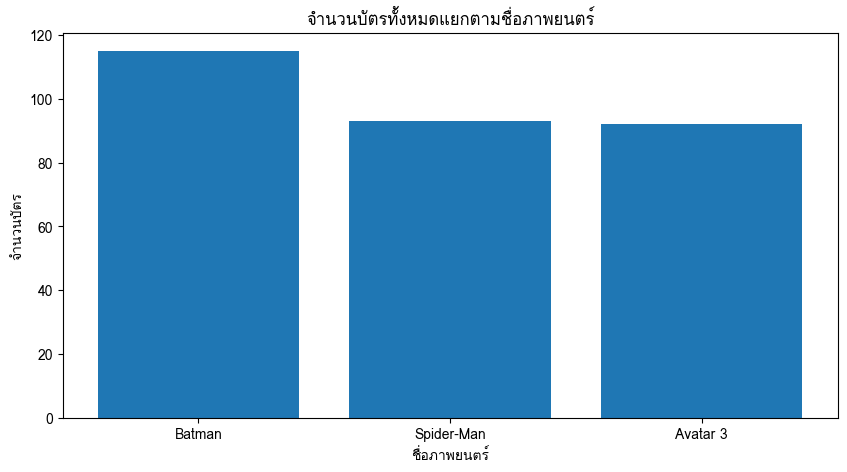

In [58]:
#จำนวนตั๋วแยกตามโรงหนัง
tickets_by_movie = (df.groupby("movie_name")["booking_id"].count().sort_values(ascending=False))
print(tickets_by_movie)
plt.figure(figsize=(10, 5))
plt.bar(tickets_by_movie.index, tickets_by_movie.values)
plt.title("จำนวนบัตรทั้งหมดแยกตามชื่อภาพยนตร์")
plt.xlabel("ชื่อภาพยนตร์")
plt.ylabel("จำนวนบัตร")
plt.show()

seat_type
VIP          142.985507
Deluxe        92.617647
Honeymoon     81.146667
Normal        75.068182
Name: price, dtype: float64


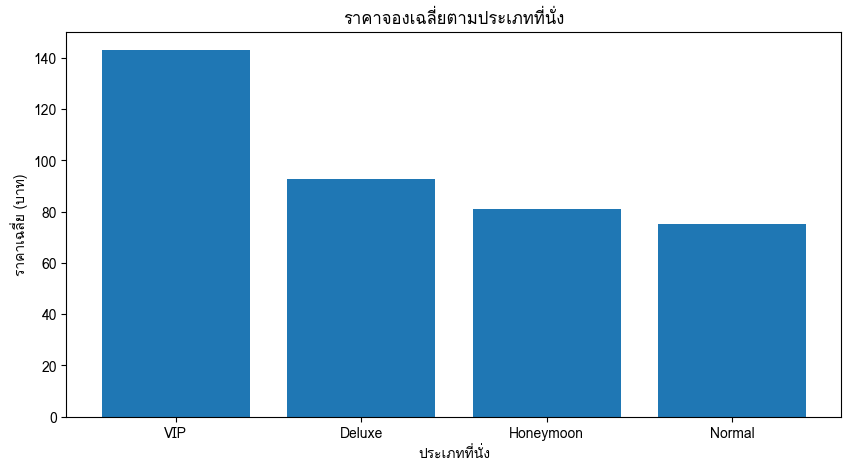

In [59]:
#ราคาจองเฉลี่ยตามประเภทที่นั่ง
import pandas as pd
df = pd.DataFrame(summary_rows)
avg_price_by_seat = (df.groupby("seat_type")["price"].mean().sort_values(ascending=False))
print(avg_price_by_seat)
plt.figure(figsize=(10, 5))
plt.bar(avg_price_by_seat.index, avg_price_by_seat.values)
plt.title("ราคาจองเฉลี่ยตามประเภทที่นั่ง")
plt.xlabel("ประเภทที่นั่ง")
plt.ylabel("ราคาเฉลี่ย (บาท)")
plt.show()

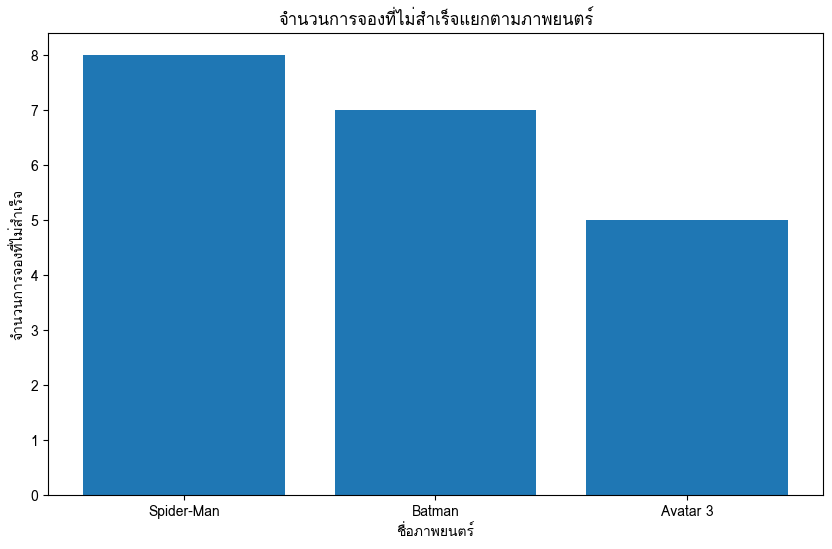

In [60]:
#การยกเลิกตั๋วหรือรายการที่ถูกปฏิเสธ
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(summary_rows)
#  กรองเฉพาะรายการ Cancelled และ Rejected แล้วนับจำนวนแยกตามภาพยนตร์
failed_by_movie = (
    df[df["status"].isin(["Cancelled", "Rejected"])]
    .groupby("movie_name")
    .size()
    .sort_values(ascending=False)
)
plt.figure(figsize=(10, 6))
bars = plt.bar(failed_by_movie.index, failed_by_movie.values)

plt.title("จำนวนการจองที่ไม่สำเร็จแยกตามภาพยนตร์")
plt.xlabel("ชื่อภาพยนตร์")
plt.ylabel("จำนวนการจองที่ไม่สำเร็จ")
plt.show()